# Homogeneous Isotropic Source Square Domain

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import pu239, research_reactor
from ttnte.iga import IGAMesh
from ttnte.sources import IsotropicInternalSource
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [2]:
# Discretization
num_nodes = 256
num_ordinates = 1024

# Get XS data
xs_server = pu239(num_groups=2)

## Vacuum Boundary Conditions and Isotropic Source

In [3]:
# Create NURBS geometry
length = 6.5 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch=cad.bilinear(points)
patches = {patch: "Pu-239"}

# Create mesh
mesh = IGAMesh(patches)

# Initialize Source
source = IsotropicInternalSource()

# Source control points
source_ctrlpts = np.zeros((xs_server.num_groups, *patch.shape))
source_ctrlpts[1, ...] = 1# cm^{-2}sec^{-1} 

# Add patch
source.add_patch(pid = 0, patch=patch, source_ctrlpts=source_ctrlpts)

# Refine mesh resolution
mesh.refine(0, factor=7, degree=3)

# Connect patches
mesh.connect(source=source)

# Finalize mesh
mesh.finalize()

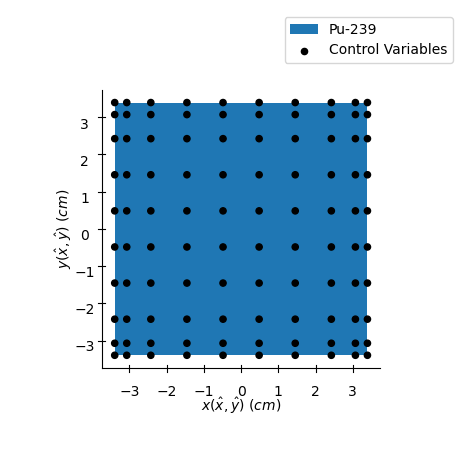

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs_is/square_vac.png", dpi=300)
plt.show()

In [5]:
# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    source=source
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, _, B_out = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_is_vac.csv")

Discretization: N = 1024, G = 2, P = 1, A = 10, B = 10
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                  1475.76        2.91
J_det           1,1,1                          35.64        5.76
R               5,25,20,16,4                    2.81       12.00
dR              5,25,35,24,7,2                  2.95       12.00
J_detRT         5,25,20,16,4                    2.81       12.61
JdR             5,25,35,24,7,2                  2.95       13.27
Intg_int        1                              50.00       15.65
Intg_str        2,2                            33.11       15.65
H               3,3,3,3,3,5                  8801.03       15.66
S               1,1,1,1,1,1               57221064.12       15.67
Jx_det_in       1,1                             4.31       18.88
Jy_det_in       1,1                             4.31       18.88
Rx_in           1,1,1,1                        42.67       18.88
Ry_in   

In [6]:
psi = fixed_source(
    LHS=LinearOperator([H, B_out, -S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    linear_solver_opts={
        "max_iterations": 50000,
        "threshold": 1e-10,
        "resets": 10,
    },
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration


OutOfMemoryError: CUDA out of memory. Tried to allocate 76.30 GiB. GPU 0 has a total capacity of 23.53 GiB of which 23.04 GiB is free. Including non-PyTorch memory, this process has 478.00 MiB memory in use. Of the allocated memory 14.39 MiB is allocated by PyTorch, and 7.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Get OpenMC solution
phi_mc = np.load("./openmc_is/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

<Figure size 640x480 with 0 Axes>

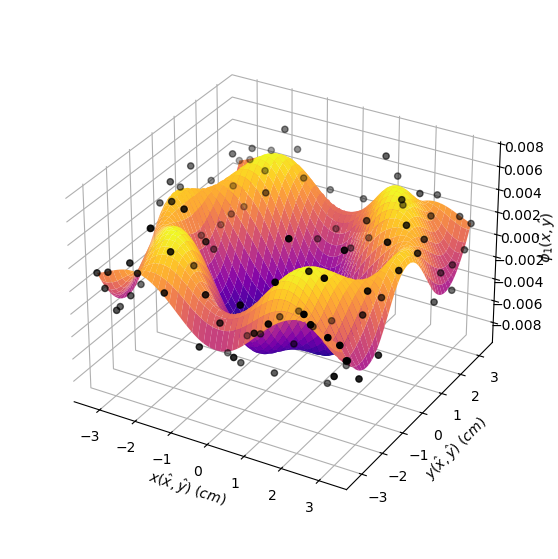

<Figure size 640x480 with 0 Axes>

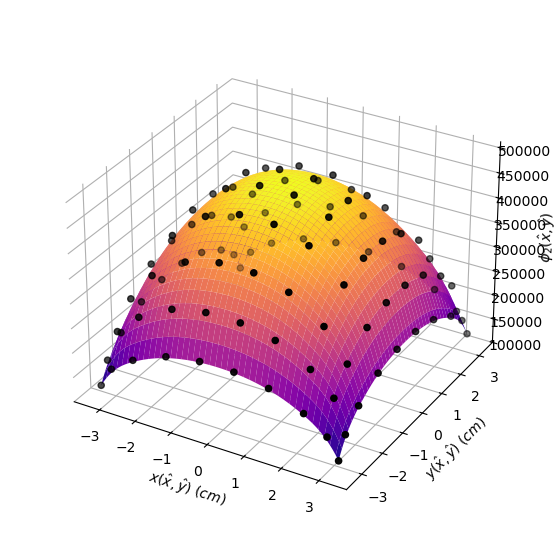

Scalar flux Relative L2-error (g = 1): 1.000000003652273
Scalar flux Relative L2-error (g = 2): 0.38822099004836014
Total scalar flux Relative L2-error: 0.7404040941374713


In [ ]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs_is/phi_{g + 1}_vac.png", dpi=300)
    plt.show()

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)

## Reflective Boundary Conditions

In [ ]:
# Create NURBS geometry
length = 3.591204 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patches = {cad.bilinear(points): "Pu-239"}

# Create mesh
mesh = IGAMesh(patches)

# Initialize Source
source = IsotropicInternalSource()

# Source control points
source_ctrlpts = np.zeros((xs_server.num_groups, *patch.shape))
source_ctrlpts[1, ...] = 1# cm^{-2}sec^{-1} 

# Add patch
source.add_patch(pid = 0, patch=patch, source_ctrlpts=source_ctrlpts)

# Refine mesh resolution
mesh.refine(0, factor=[3, 9], degree=3)

# Connect patches
mesh.connect(source=source)

# Set reflective boundary conditions
mesh.set_reflective_condition(("top", "bottom"))

# Finalize mesh
mesh.finalize()

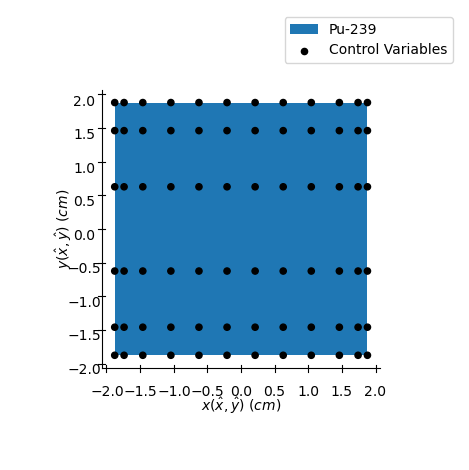

In [ ]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs_is/square_ref.png", dpi=300)
plt.show()

In [ ]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    source=source
)

# Set builder settings
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, B_in, B_out = assembler.build(use_tt=True)

# Save TT information
assembler.save_tt_info("./tt_info_is_ref.csv")

Discretization: N = 1024, G = 2, P = 1, A = 6, B = 12
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                   864.00        0.54
J_det           1,1,1                          21.60        1.07
R               3,15,12,16,4                    3.18        1.22
dR              3,15,21,24,7,2                  3.13        1.23
J_detRT         3,15,12,16,4                    3.18        1.23
JdR             3,15,21,24,7,2                  3.13        1.24
Intg_int        1                              28.80        1.54
Intg_str        2,2                            15.90        1.54
H               3,3,3,3,3,5                  6689.88        1.54
S               1,1,1,1,1,1               30495472.56        1.54
F               1,1,1,1,1,1               30495472.56        1.54
Jx_det_in       1,1                             2.67        1.76
Jy_det_in       1,1                             4.80        1.76
Rx_in   

In [ ]:
psi = fixed_source(
    LHS=LinearOperator([H, B_out, -S, -B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

NameError: name 'eig' is not defined

<Figure size 640x480 with 0 Axes>

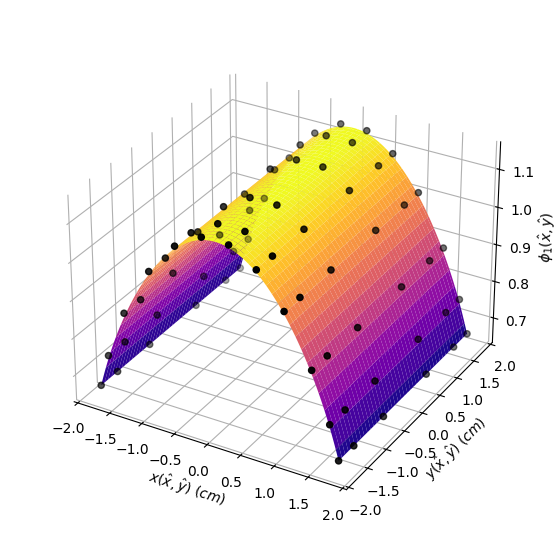

<Figure size 640x480 with 0 Axes>

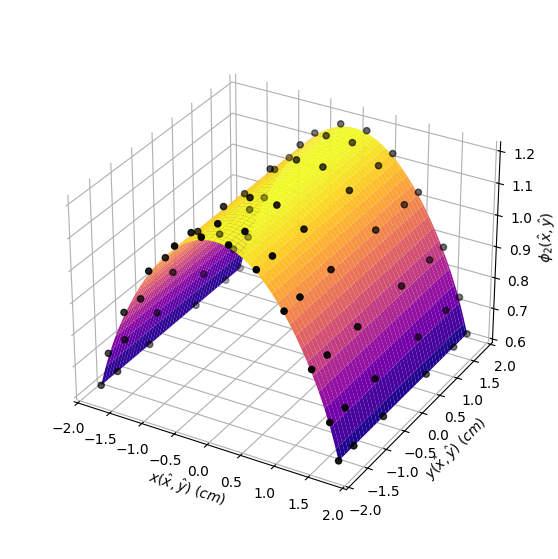

In [ ]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs_is/phi_{g + 1}_ref.png", dpi=300)
    plt.show()

## Linearly Anisotropic

In [ ]:
# Get XS data
xs_server = research_reactor(is_anisotropic=True)

# Create NURBS geometry
length = 9.4959 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patches = {cad.bilinear(points): "Research Reactor"}

# Create mesh
mesh = IGAMesh(patches)

# Initialize Source
source = IsotropicInternalSource()

# Source control points
source_ctrlpts = np.zeros((xs_server.num_groups, *patch.shape))
source_ctrlpts[1, ...] = 1# cm^{-2}sec^{-1} 

# Add patch
source.add_patch(pid = 0, patch=patch, source_ctrlpts=source_ctrlpts)

# Refine mesh resolution
mesh.refine(0, factor=[5, 7], degree=3)

# Connect patches
mesh.connect(source=source)

# Define boundary conditions
mesh.set_reflective_condition(("left", "top", "bottom"))

# Finalize mesh
mesh.finalize()

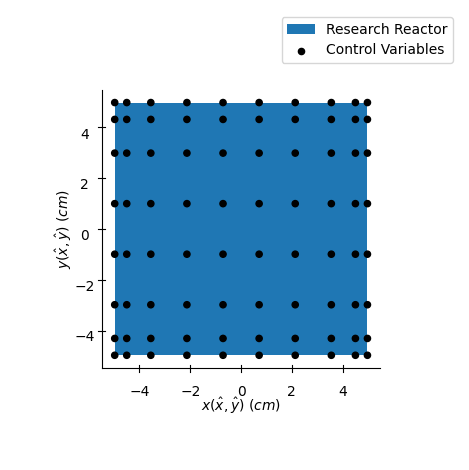

In [ ]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs_is/square_anisotropic.png", dpi=300)
plt.show()

In [ ]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    source=source,
)

# Set builder settings
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, B_in, B_out = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_is_anisotropic.csv")

Discretization: N = 1024, G = 2, P = 1, A = 8, B = 10
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                  1120.00        0.53
J_det           1,1,1                          28.00        1.05
R               5,25,20,16,4                    2.01        1.26
dR              5,25,35,24,7,2                  2.11        1.26
J_detRT         5,25,20,16,4                    2.01        1.27
JdR             5,25,35,24,7,2                  2.11        1.28
Intg_int        1                              39.02        1.68
Intg_str        2,2                            24.06        1.68
H               3,3,3,3,3,5                  7334.75        1.68
S               3,3,2,1,1,1               6610082.64        1.68
F               1,1,1,1,1,1               38512977.91        1.68
Jx_det_in       1,1                             3.64        1.86
Jy_det_in       1,1                             4.31        1.86
Rx_in    

In [ ]:
psi = fixed_source(
    LHS=LinearOperator([H, B_out, -S, -B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.9043517, Angular Flux L2-Error = 1.21615946, Elapsed Time = 2.539
-- (1): k = 0.98619096, Angular Flux L2-Error = 0.1402703, Elapsed Time = 4.965
-- (2): k = 0.99748486, Angular Flux L2-Error = 0.02174288, Elapsed Time = 7.386
-- (3): k = 0.99949277, Angular Flux L2-Error = 0.00405318, Elapsed Time = 9.79
-- (4): k = 0.99987126, Angular Flux L2-Error = 0.0007757, Elapsed Time = 12.243
-- (5): k = 0.99994376, Angular Flux L2-Error = 0.00014928, Elapsed Time = 14.701
-- (6): k = 0.99995771, Angular Flux L2-Error = 2.877e-05, Elapsed Time = 17.086
-- (7): k = 0.9999604, Angular Flux L2-Error = 5.55e-06, Elapsed Time = 19.065
-- (8): k = 0.99996092, Angular Flux L2-Error = 1.07e-06, Elapsed Time = 20.424
-- (9): k = 0.99996102, Angular Flux L2-Error = 2.1e-07, Elapsed Time = 21.43
-- (10): k = 0.99996104, Angular Flux L2-Error = 4e-08, Elapsed Time = 22.016
-- (11): k = 0.99996104, Angular Flux L2-Error = 1e-08, Elapsed Time = 22.396
-- Converged: k =

<Figure size 640x480 with 0 Axes>

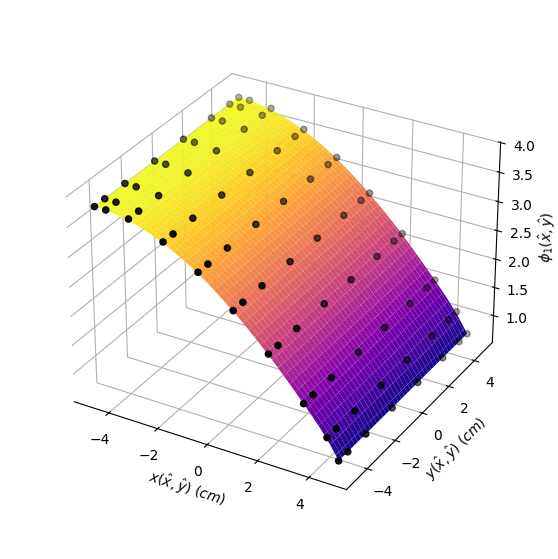

<Figure size 640x480 with 0 Axes>

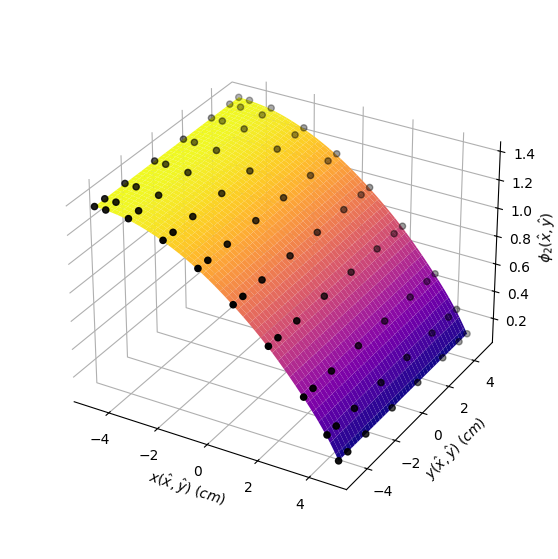

In [ ]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs_is/phi_{g + 1}_anisotropic.png", dpi=300)
    plt.show()